# California Housing Price Predictor

This project builds a machine learning model to predict California house prices using features such as location, population, and housing characteristics. The model was trained using a pipeline and deployed as an interactive web app with Streamlit.

A baseline model was first established using the mean house value to provide a benchmark. A Linear Regression model was then trained using a pipeline that integrates preprocessing steps such as one-hot encoding for categorical variables. The model significantly improved prediction accuracy, reducing the error by approximately 40% compared to the baseline.

In [1]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


Importing all the required libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import folium
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import joblib

Loading the dataset from a CSV file into a DataFrame

In [4]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


The number of rows and columns

In [5]:
df.shape

(20640, 10)

The total number of missing (null) values in each column


In [6]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Removing all rows in the dataset that contain missing (null) values

In [7]:
df.dropna(inplace=True)

The total number of missing (null) values in each column

In [8]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Column’s data type

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


The distinct categories present in the ocean_proximity feature

In [10]:
df["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

The heatmap shows the correlation between numerical features in the dataset

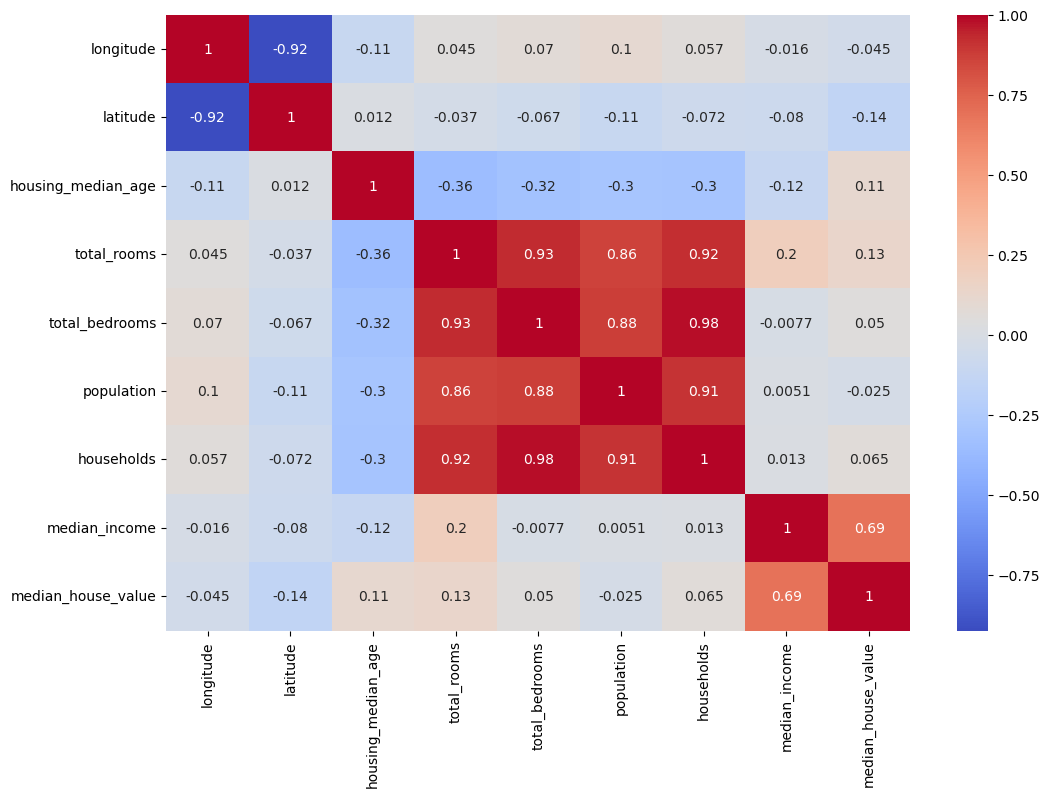

In [11]:
cor = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(data=cor, annot=True, cmap="coolwarm");

Map showing sampled housing locations and their median values across California.

In [12]:
m = folium.Map(
    location=[df["latitude"].mean(), df["longitude"].mean()],
    zoom_start=6
)

# Add points with value
for _, row in df.sample(500).iterrows():  # limit points for speed
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color="blue",
        fill=True,
        fill_opacity=0.6,
        tooltip=f"House Value: ${row['median_house_value']:,.0f}"
    ).add_to(m)

m

Separating the dataset into features (input variables) and the target variable (house price).

In [13]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

Spliting the dataset into training and testing sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Creating a baseline prediction

In [15]:
# Baseline model
baseline = y_train.mean()
baseline_pred = [baseline] * len(y_test)



Preparing the categorical data

In [16]:
categorical = ["ocean_proximity"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
], remainder="passthrough")

Machine learning pipeline

In [17]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

Model training using the training data

In [18]:
model.fit(X_train, y_train)

C:\Users\USER\anaconda3\envs\MachineLearningDataScience\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ocean_proximity'])])),
                ('regressor', LinearRegression())])

The trained pipeline generates predictions for the unseen test dataset

In [19]:
y_pred = model.predict(X_test)


Calculating the Root Mean Squared Error (RMSE)

In [20]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 69297.71669112946


Comparing the baseline_rmse and the models_rmse

In [21]:
# 👉 ADD IT HERE
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print("Baseline RMSE:", baseline_rmse)


# Your actual model
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Model RMSE:", rmse)

Baseline RMSE: 116946.10165720902
Model RMSE: 69297.71669112946


Saving the trained model to a file

In [22]:
joblib.dump(model, "model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


Runs the Streamlit app

In [ ]:
!streamlit run app.py